# Analisis Regresi Linier

Notebook ini berisi penjelasan detail mengenai **Regresi Linier Sederhana** (*Simple Linear Regression*) dan pengimplementasiannya menggunakan dua pendekatan:
1. **Menggunakan Library Scikit-Learn** (`LinearRegression`)
2. **Perhitungan Analitik (Manual)** menggunakan rumus koefisien regresi

### Data Soal
Diberikan 7 titik data:

| Titik | X | Y |
|-------|---|---|
| A | 2 | 2 |
| B | 4 | 3 |
| C | 3 | 5 |
| D | 3 | 4 |
| E | 3 | 3 |
| F | 4 | 5 |
| G | 5 | 6 |

![Soal Regresi Linier](data/Regresi_Linier/soal.jpeg)

## 1. Teori Regresi Linier Sederhana

**Regresi Linier Sederhana** adalah metode statistik yang digunakan untuk memodelkan hubungan linier antara satu variabel independen ($X$) dan satu variabel dependen ($Y$).

### Persamaan Garis Regresi

$$\hat{Y} = b_0 + b_1 \cdot X$$

Di mana:
- $\hat{Y}$ : Nilai prediksi variabel dependen
- $b_0$ : **Intercept** (konstanta) — titik potong garis regresi dengan sumbu Y
- $b_1$ : **Slope** (koefisien regresi) — kemiringan garis regresi
- $X$ : Variabel independen

### Rumus Koefisien Regresi (Metode Least Square)

**Slope ($b_1$):**

$$b_1 = \frac{n \sum X_i Y_i - \sum X_i \sum Y_i}{n \sum X_i^2 - (\sum X_i)^2}$$

**Intercept ($b_0$):**

$$b_0 = \bar{Y} - b_1 \cdot \bar{X}$$

Di mana:
- $n$ : Jumlah data
- $\bar{X}$ : Rata-rata nilai X
- $\bar{Y}$ : Rata-rata nilai Y

## 2. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Persiapan Data

Memasukkan data dari soal ke dalam DataFrame.

In [2]:
# Data dari soal
data = {
    'Titik': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'X': [2, 4, 3, 3, 3, 4, 5],
    'Y': [2, 3, 5, 4, 3, 5, 6]
}

df = pd.DataFrame(data)
print("=" * 40)
print("        DATA TITIK KOORDINAT")
print("=" * 40)
print(df.to_string(index=False))
print(f"\nJumlah data (n) = {len(df)}")

        DATA TITIK KOORDINAT
Titik  X  Y
    A  2  2
    B  4  3
    C  3  5
    D  3  4
    E  3  3
    F  4  5
    G  5  6

Jumlah data (n) = 7


---
## 4. Metode 1: Menggunakan Scikit-Learn (`LinearRegression`)

Scikit-Learn menyediakan class `LinearRegression` yang secara otomatis menghitung koefisien regresi menggunakan metode **Ordinary Least Squares (OLS)**.

In [3]:
# Menyiapkan data untuk sklearn (X harus berbentuk 2D)
X = df['X'].values.reshape(-1, 1)
Y = df['Y'].values

# Membuat dan melatih model
model = LinearRegression()
model.fit(X, Y)

# Mengambil koefisien
b1_sklearn = model.coef_[0]       # Slope
b0_sklearn = model.intercept_     # Intercept
r_squared = model.score(X, Y)     # R-squared

print("=" * 50)
print("  HASIL REGRESI LINIER (Scikit-Learn)")
print("=" * 50)
print(f"  Slope (b1)     = {b1_sklearn:.4f}")
print(f"  Intercept (b0) = {b0_sklearn:.4f}")
print(f"  R-squared (R²) = {r_squared:.4f}")
print(f"\n  Persamaan Regresi: Y = {b0_sklearn:.4f} + {b1_sklearn:.4f} * X")
print("=" * 50)

  HASIL REGRESI LINIER (Scikit-Learn)
  Slope (b1)     = 1.0500
  Intercept (b0) = 0.4000
  R-squared (R²) = 0.5250

  Persamaan Regresi: Y = 0.4000 + 1.0500 * X


In [4]:
# Prediksi nilai Y menggunakan model sklearn
Y_pred_sklearn = model.predict(X)

df_hasil_sklearn = df.copy()
df_hasil_sklearn['Y_prediksi'] = np.round(Y_pred_sklearn, 4)
df_hasil_sklearn['Residual'] = np.round(Y - Y_pred_sklearn, 4)

print("\nHasil Prediksi (Scikit-Learn):")
print(df_hasil_sklearn.to_string(index=False))


Hasil Prediksi (Scikit-Learn):
Titik  X  Y  Y_prediksi  Residual
    A  2  2        2.50     -0.50
    B  4  3        4.60     -1.60
    C  3  5        3.55      1.45
    D  3  4        3.55      0.45
    E  3  3        3.55     -0.55
    F  4  5        4.60      0.40
    G  5  6        5.65      0.35


---
## 5. Metode 2: Perhitungan Analitik (Manual)

Pada bagian ini, kita akan menghitung koefisien regresi **secara manual** menggunakan rumus Least Square untuk membuktikan hasilnya sama dengan Scikit-Learn.

In [5]:
# Variabel dasar
Xi = df['X'].values
Yi = df['Y'].values
n = len(Xi)

# Membuat tabel perhitungan
df_calc = pd.DataFrame({
    'Titik': df['Titik'],
    'Xi': Xi,
    'Yi': Yi,
    'Xi²': Xi ** 2,
    'Yi²': Yi ** 2,
    'Xi·Yi': Xi * Yi
})

# Menghitung total
sum_Xi = np.sum(Xi)
sum_Yi = np.sum(Yi)
sum_Xi2 = np.sum(Xi ** 2)
sum_Yi2 = np.sum(Yi ** 2)
sum_XiYi = np.sum(Xi * Yi)

print("=" * 55)
print("       TABEL PERHITUNGAN ANALITIK")
print("=" * 55)
print(df_calc.to_string(index=False))
print("-" * 55)
print(f"  Σ     {sum_Xi:5}  {sum_Yi:5}  {sum_Xi2:5}  {sum_Yi2:5}  {sum_XiYi:7}")
print("=" * 55)

       TABEL PERHITUNGAN ANALITIK
Titik  Xi  Yi  Xi²  Yi²  Xi·Yi
    A   2   2    4    4      4
    B   4   3   16    9     12
    C   3   5    9   25     15
    D   3   4    9   16     12
    E   3   3    9    9      9
    F   4   5   16   25     20
    G   5   6   25   36     30
-------------------------------------------------------
  Σ        24     28     88    124      102


In [6]:
# Menghitung rata-rata
X_bar = sum_Xi / n
Y_bar = sum_Yi / n

print("=" * 50)
print("     PERHITUNGAN KOEFISIEN REGRESI")
print("=" * 50)
print(f"\n  n       = {n}")
print(f"  ΣXi     = {sum_Xi}")
print(f"  ΣYi     = {sum_Yi}")
print(f"  ΣXi²    = {sum_Xi2}")
print(f"  ΣXi·Yi  = {sum_XiYi}")
print(f"  X̄ (rata-rata X) = {X_bar:.4f}")
print(f"  Ȳ (rata-rata Y) = {Y_bar:.4f}")

# Menghitung b1 (Slope)
pembilang_b1 = n * sum_XiYi - sum_Xi * sum_Yi
penyebut_b1 = n * sum_Xi2 - sum_Xi ** 2
b1_analitik = pembilang_b1 / penyebut_b1

print(f"\n--- Menghitung Slope (b1) ---")
print(f"  Pembilang = n·ΣXiYi - ΣXi·ΣYi")
print(f"            = {n}×{sum_XiYi} - {sum_Xi}×{sum_Yi}")
print(f"            = {n * sum_XiYi} - {sum_Xi * sum_Yi}")
print(f"            = {pembilang_b1}")
print(f"  Penyebut  = n·ΣXi² - (ΣXi)²")
print(f"            = {n}×{sum_Xi2} - {sum_Xi}²")
print(f"            = {n * sum_Xi2} - {sum_Xi ** 2}")
print(f"            = {penyebut_b1}")
print(f"  b1 = {pembilang_b1} / {penyebut_b1} = {b1_analitik:.4f}")

# Menghitung b0 (Intercept)
b0_analitik = Y_bar - b1_analitik * X_bar

print(f"\n--- Menghitung Intercept (b0) ---")
print(f"  b0 = Ȳ - b1·X̄")
print(f"     = {Y_bar:.4f} - {b1_analitik:.4f}×{X_bar:.4f}")
print(f"     = {Y_bar:.4f} - {b1_analitik * X_bar:.4f}")
print(f"     = {b0_analitik:.4f}")

print(f"\n{'=' * 50}")
print(f"  PERSAMAAN REGRESI (Analitik):")
print(f"  Ŷ = {b0_analitik:.4f} + {b1_analitik:.4f} · X")
print(f"{'=' * 50}")

     PERHITUNGAN KOEFISIEN REGRESI

  n       = 7
  ΣXi     = 24
  ΣYi     = 28
  ΣXi²    = 88
  ΣXi·Yi  = 102
  X̄ (rata-rata X) = 3.4286
  Ȳ (rata-rata Y) = 4.0000

--- Menghitung Slope (b1) ---
  Pembilang = n·ΣXiYi - ΣXi·ΣYi
            = 7×102 - 24×28
            = 714 - 672
            = 42
  Penyebut  = n·ΣXi² - (ΣXi)²
            = 7×88 - 24²
            = 616 - 576
            = 40
  b1 = 42 / 40 = 1.0500

--- Menghitung Intercept (b0) ---
  b0 = Ȳ - b1·X̄
     = 4.0000 - 1.0500×3.4286
     = 4.0000 - 3.6000
     = 0.4000

  PERSAMAAN REGRESI (Analitik):
  Ŷ = 0.4000 + 1.0500 · X


In [7]:
# Prediksi Y menggunakan rumus analitik
Y_pred_analitik = b0_analitik + b1_analitik * Xi

df_hasil_analitik = df.copy()
df_hasil_analitik['Y_prediksi'] = np.round(Y_pred_analitik, 4)
df_hasil_analitik['Residual'] = np.round(Yi - Y_pred_analitik, 4)

print("\nHasil Prediksi (Analitik):")
print(df_hasil_analitik.to_string(index=False))


Hasil Prediksi (Analitik):
Titik  X  Y  Y_prediksi  Residual
    A  2  2        2.50     -0.50
    B  4  3        4.60     -1.60
    C  3  5        3.55      1.45
    D  3  4        3.55      0.45
    E  3  3        3.55     -0.55
    F  4  5        4.60      0.40
    G  5  6        5.65      0.35


---
## 6. Menghitung R² (Koefisien Determinasi) Secara Analitik

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Di mana:
- $SS_{res} = \sum (Y_i - \hat{Y}_i)^2$ (Sum of Squared Residuals)
- $SS_{tot} = \sum (Y_i - \bar{Y})^2$ (Total Sum of Squares)

In [8]:
# Menghitung R² secara analitik
SS_res = np.sum((Yi - Y_pred_analitik) ** 2)
SS_tot = np.sum((Yi - Y_bar) ** 2)
R2_analitik = 1 - (SS_res / SS_tot)

# Koefisien Korelasi (r)
r_analitik = np.sqrt(R2_analitik) if b1_analitik > 0 else -np.sqrt(R2_analitik)

print("=" * 50)
print("  KOEFISIEN DETERMINASI & KORELASI")
print("=" * 50)
print(f"  SS_res (Sum Sq. Residuals)  = {SS_res:.4f}")
print(f"  SS_tot (Total Sum Sq.)      = {SS_tot:.4f}")
print(f"  R² (Koef. Determinasi)      = {R2_analitik:.4f}")
print(f"  r  (Koef. Korelasi)         = {r_analitik:.4f}")
print(f"\n  Interpretasi: {R2_analitik*100:.2f}% variasi Y dapat")
print(f"  dijelaskan oleh variabel X.")
print("=" * 50)

  KOEFISIEN DETERMINASI & KORELASI
  SS_res (Sum Sq. Residuals)  = 5.7000
  SS_tot (Total Sum Sq.)      = 12.0000
  R² (Koef. Determinasi)      = 0.5250
  r  (Koef. Korelasi)         = 0.7246

  Interpretasi: 52.50% variasi Y dapat
  dijelaskan oleh variabel X.


---
## 7. Perbandingan Hasil: Scikit-Learn vs Analitik

In [9]:
# Membandingkan hasil kedua metode
comparison = pd.DataFrame({
    'Parameter': ['Slope (b1)', 'Intercept (b0)', 'R²'],
    'Scikit-Learn': [round(b1_sklearn, 4), round(b0_sklearn, 4), round(r_squared, 4)],
    'Analitik': [round(b1_analitik, 4), round(b0_analitik, 4), round(R2_analitik, 4)],
    'Selisih': [
        round(abs(b1_sklearn - b1_analitik), 10),
        round(abs(b0_sklearn - b0_analitik), 10),
        round(abs(r_squared - R2_analitik), 10)
    ]
})

print("=" * 60)
print("    PERBANDINGAN: Scikit-Learn vs Analitik")
print("=" * 60)
print(comparison.to_string(index=False))
print("\n✅ Hasil kedua metode IDENTIK (selisih = 0)")

    PERBANDINGAN: Scikit-Learn vs Analitik
     Parameter  Scikit-Learn  Analitik  Selisih
    Slope (b1)         1.050     1.050      0.0
Intercept (b0)         0.400     0.400      0.0
            R²         0.525     0.525      0.0

✅ Hasil kedua metode IDENTIK (selisih = 0)


---
## 8. Visualisasi Regresi Linier

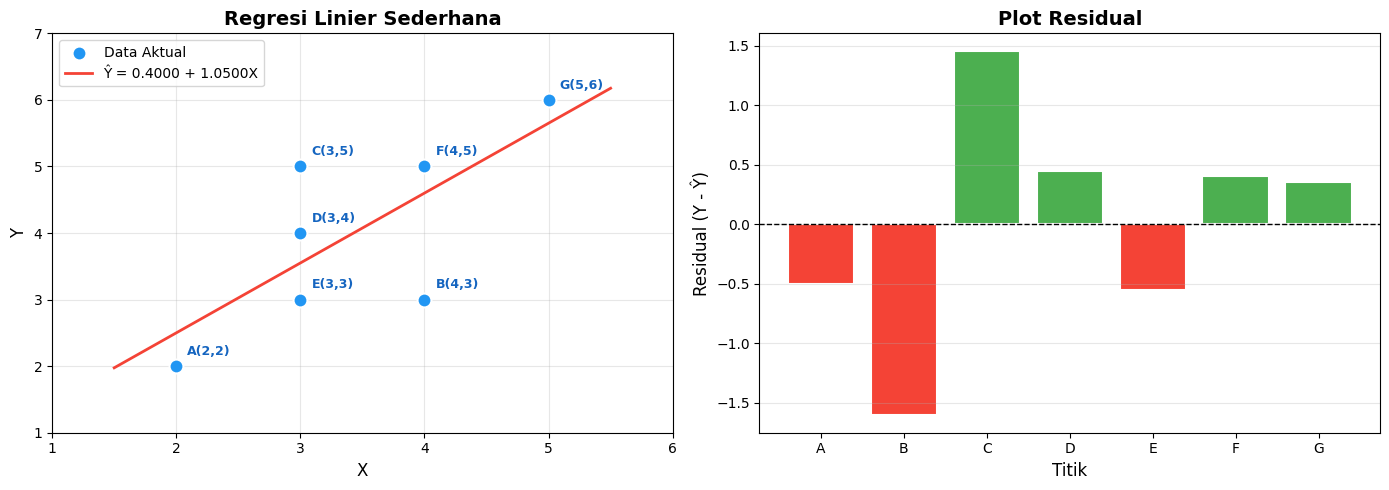


📊 Grafik disimpan ke: data/Regresi_Linier/regresi_linier_plot.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Scatter + Garis Regresi ===
ax1 = axes[0]
ax1.scatter(Xi, Yi, color='#2196F3', s=100, zorder=5, edgecolors='white', linewidths=1.5, label='Data Aktual')

# Garis regresi
x_line = np.linspace(min(Xi) - 0.5, max(Xi) + 0.5, 100)
y_line = b0_analitik + b1_analitik * x_line
ax1.plot(x_line, y_line, color='#F44336', linewidth=2, label=f'Ŷ = {b0_analitik:.4f} + {b1_analitik:.4f}X')

# Label titik
for i, titik in enumerate(df['Titik']):
    ax1.annotate(f'{titik}({Xi[i]},{Yi[i]})', (Xi[i], Yi[i]),
                 textcoords='offset points', xytext=(8, 8),
                 fontsize=9, fontweight='bold', color='#1565C0')

ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title('Regresi Linier Sederhana', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, 6)
ax1.set_ylim(1, 7)

# === Plot 2: Residual Plot ===
ax2 = axes[1]
residuals = Yi - Y_pred_analitik
ax2.bar(df['Titik'], residuals, color=['#4CAF50' if r >= 0 else '#F44336' for r in residuals],
        edgecolor='white', linewidth=1.5)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Titik', fontsize=12)
ax2.set_ylabel('Residual (Y - Ŷ)', fontsize=12)
ax2.set_title('Plot Residual', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/Regresi_Linier/regresi_linier_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Grafik disimpan ke: data/Regresi_Linier/regresi_linier_plot.png")

---
## 9. Implementasi di GeoGebra

**GeoGebra** adalah software matematika dinamis yang dapat digunakan untuk memvisualisasikan dan menghitung regresi linier secara interaktif.

### Cara Implementasi di GeoGebra (Step-by-Step)

#### Langkah 1: Buka GeoGebra
- Buka **GeoGebra Classic** melalui browser di [geogebra.org/classic](https://www.geogebra.org/classic), atau gunakan aplikasi desktop GeoGebra.
- Pastikan tampilan **Grafik (Graphics)** dan **Aljabar (Algebra)** aktif.

#### Langkah 2: Masukkan Titik-Titik Data
Pada **kolom input** di bagian kiri/bawah, ketikkan perintah berikut satu per satu lalu tekan **Enter**:

```
A = (2, 2)
B = (4, 3)
C = (3, 5)
D = (3, 4)
E = (3, 3)
F = (4, 5)
G = (5, 6)
```

Setiap perintah akan membuat sebuah titik pada bidang koordinat. Titik-titik akan muncul di panel **Aljabar** dan di **Grafik**.

#### Langkah 3: Buat Garis Regresi dengan FitLine
Setelah semua titik dimasukkan, ketikkan perintah berikut pada kolom input:

```
FitLine({A, B, C, D, E, F, G})
```

Perintah `FitLine` akan secara otomatis menghitung garis regresi linier menggunakan metode **Least Squares** dan menampilkan hasilnya.

#### Langkah 4: Lihat Hasil
Di panel **Aljabar**, akan muncul persamaan garis regresi:

$$f: y = 1.05x + 0.4$$

Hasil ini **IDENTIK** dengan perhitungan analitik dan Scikit-Learn:
- **Slope (b1) = 1.05**
- **Intercept (b0) = 0.4**

### Hasil GeoGebra

![Hasil Regresi Linier di GeoGebra](data/Regresi_Linier/geogebra.png)

### Perintah GeoGebra Lainnya yang Berguna

| Perintah | Fungsi |
|----------|--------|
| `FitLine({A,B,C,D,E,F,G})` | Garis regresi linier (Least Squares) |
| `FitPoly({A,B,C,D,E,F,G}, 2)` | Regresi polinomial derajat 2 |
| `FitExp({A,B,C,D,E,F,G})` | Regresi eksponensial |
| `FitLog({A,B,C,D,E,F,G})` | Regresi logaritmik |
| `RSquare(f, {A,B,C,D,E,F,G})` | Menghitung nilai R² |

> **Catatan:** Untuk menghitung R² di GeoGebra, gunakan perintah `RSquare(f, {A,B,C,D,E,F,G})` setelah membuat garis regresi `f`.

---
## 10. Kesimpulan

Dari analisis Regresi Linier Sederhana pada 7 titik data menggunakan **tiga metode** (Scikit-Learn, Analitik, dan GeoGebra), diperoleh hasil sebagai berikut:

In [11]:
print("╔" + "═" * 58 + "╗")
print("║" + "          RINGKASAN HASIL ANALISIS".ljust(58) + "║")
print("╠" + "═" * 58 + "╣")
print(f"║  Persamaan Regresi : Ŷ = {b0_analitik:.4f} + {b1_analitik:.4f}·X".ljust(58) + " ║")
print(f"║  Slope (b1)        : {b1_analitik:.4f}".ljust(58) + " ║")
print(f"║  Intercept (b0)    : {b0_analitik:.4f}".ljust(58) + " ║")
print(f"║  R² (Determinasi)  : {R2_analitik:.4f} ({R2_analitik*100:.2f}%)".ljust(58) + " ║")
print(f"║  r (Korelasi)      : {r_analitik:.4f}".ljust(58) + " ║")
print("╠" + "═" * 58 + "╣")
print("║  Interpretasi:".ljust(58) + " ║")
print(f"║  • Setiap kenaikan 1 unit X, Y naik {b1_analitik:.4f} unit".ljust(58) + " ║")
print(f"║  • {R2_analitik*100:.2f}% variasi Y dijelaskan oleh X".ljust(58) + " ║")
print(f"║  • Hubungan X dan Y bersifat POSITIF & cukup kuat".ljust(58) + " ║")
print("║  • Hasil sklearn dan analitik IDENTIK ✅".ljust(58) + " ║")
print("╚" + "═" * 58 + "╝")

╔══════════════════════════════════════════════════════════╗
║          RINGKASAN HASIL ANALISIS                        ║
╠══════════════════════════════════════════════════════════╣
║  Persamaan Regresi : Ŷ = 0.4000 + 1.0500·X               ║
║  Slope (b1)        : 1.0500                              ║
║  Intercept (b0)    : 0.4000                              ║
║  R² (Determinasi)  : 0.5250 (52.50%)                     ║
║  r (Korelasi)      : 0.7246                              ║
╠══════════════════════════════════════════════════════════╣
║  Interpretasi:                                           ║
║  • Setiap kenaikan 1 unit X, Y naik 1.0500 unit          ║
║  • 52.50% variasi Y dijelaskan oleh X                    ║
║  • Hubungan X dan Y bersifat POSITIF & cukup kuat        ║
║  • Hasil sklearn dan analitik IDENTIK ✅                  ║
╚══════════════════════════════════════════════════════════╝
